# Hyperparameter Optimization for TF-IDF and Semantic Search Weights

This notebook evaluates hybrid TF-IDF + semantic weight combinations in two stages:

1. **Hybrid retrieval only** (no legal reranking) — identifies which weights produce the best lexical/semantic candidate pool.
2. **Full pipeline with legal reranking** — the production system metric. The reranker is additive on hybrid scores, so the best *hybrid-only* weights are not always best for the complete system.

The goal is to justify **0.6/0.4**: it leaves enough semantic signal for the legal reranker to reorder results effectively, outperforming 0.7/0.3 after reranking even though 0.7/0.3 can look slightly better on hybrid-only metrics.

## 1. Setup and Imports

Import the required libraries, configure the project root, and initialize the notebook environment for the retrieval experiment.

In [18]:
import os
import sys
import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.sparse import load_npz
from sklearn.metrics.pairwise import cosine_similarity
from fastembed import TextEmbedding
import joblib
import warnings
from dotenv import load_dotenv
warnings.filterwarnings('ignore')

# Load environment variables for credentials
load_dotenv()

# Add project root to path
# Handle both cases: running from notebooks/ dir or project root
current_path = Path().absolute()
if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    # If running from elsewhere, assume project root is current or parent
    if (current_path / "index").exists():
        project_root = current_path
    elif (current_path.parent / "index").exists():
        project_root = current_path.parent
    else:
        project_root = current_path.parent

sys.path.insert(0, str(project_root))

# Run from the project root so relative paths and translation cache match the app
os.chdir(project_root)

# Set cache path for fastembed
os.environ["FASTEMBED_CACHE_PATH"] = str(project_root / "models")

# Point Google Translate credentials to the repo secrets file when available
credential_path = project_root / "secrets" / "cameroon-laws-ir-9d9895228931.json"
if credential_path.exists():
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = str(credential_path)

# Load environment variables from the project root when present
load_dotenv(project_root / ".env")

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Project root: {project_root}")
print(f"Current directory: {Path.cwd()}")
print("Setup complete!")

Project root: /Users/pro-3ies/Desktop/final year/cameroon-laws-ir
Current directory: /Users/pro-3ies/Desktop/final year/cameroon-laws-ir
Setup complete!


## 2. Configure Paths and Granularity

Set the active retrieval granularity and resolve the index and legal-resource paths relative to the project root before loading the search assets.

## 3. Load Search Resources

Load the TF-IDF matrices, inverted indexes, embeddings, and unit ID mappings for both languages so the search function can rank documents.

In [19]:
from src.legal_reranker import rerank_results
from src.tfidf_search import (
    expand_query,
    preprocess_query,
    get_candidate_indices,
    _combine_and_sort,
    load_resources,
    embedding_model,
)
from src.utils import CONFIG, detect_language, translate_text

# Load configuration
granularity = "clause"
config = CONFIG[granularity]
index_dir = project_root / config["index_dir"]
legal_dir = config["legal_dir"]  # relative path; notebook runs from project root

print(f"Using granularity: {granularity}")
print(f"Index directory: {index_dir}")
print(f"Legal directory: {project_root / legal_dir}")

Using granularity: clause
Index directory: /Users/pro-3ies/Desktop/final year/cameroon-laws-ir/index
Legal directory: /Users/pro-3ies/Desktop/final year/cameroon-laws-ir/data/legal_units


In [20]:
# Use the same resource loader and embedding model as src/tfidf_search.py
resources = load_resources(granularity)

for language in ["en", "fr"]:
    lang_resources = resources[language]
    print(f"Loading {language} resources...")
    print(f"  Loaded {len(lang_resources['unit_ids'])} documents")
    print(f"  TF-IDF matrix shape: {lang_resources['tfidf_matrix'].shape}")
    print(f"  Embeddings shape: {lang_resources['embeddings'].shape}")

print("\nAll resources loaded successfully!")

Loading en resources...
  Loaded 4174 documents
  TF-IDF matrix shape: (4174, 9923)
  Embeddings shape: (4174, 384)
Loading fr resources...
  Loaded 411 documents
  TF-IDF matrix shape: (411, 2488)
  Embeddings shape: (411, 384)

All resources loaded successfully!


## 4. Implement Search Function with Custom Weights

Define the hybrid retrieval function that combines TF-IDF and semantic similarity using configurable weights.

In [21]:
def _search_single_language(
    query: str,
    language: str,
    tfidf_weight: float,
    semantic_weight: float,
    top_k: int = 10,
):
    """Mirror search_single_language() in src/tfidf_search.py with custom weights."""
    lang_resources = resources[language]

    # Must expand first, then preprocess the expanded query (same as the app)
    expanded_query = expand_query(query)
    processed_query = preprocess_query(expanded_query)
    query_tokens = processed_query.split()

    vectorizer = lang_resources["vectorizer"]
    tfidf_matrix = lang_resources["tfidf_matrix"]
    embeddings = lang_resources["embeddings"]
    unit_ids = lang_resources["unit_ids"]

    query_vector = vectorizer.transform([processed_query])
    query_embedding = list(embedding_model.embed([expanded_query]))[0]

    candidate_indices = get_candidate_indices(query_tokens, lang_resources)

    tfidf_scores_global = cosine_similarity(query_vector, tfidf_matrix)[0]

    if candidate_indices:
        candidate_indices = set(candidate_indices)
        fallback_indices = np.argsort(tfidf_scores_global)[::-1][:100]
        candidate_indices.update(fallback_indices)
        candidate_indices = list(candidate_indices)
    else:
        candidate_indices = np.argsort(tfidf_scores_global)[::-1][:100]

    tfidf_subset = tfidf_matrix[candidate_indices]
    embedding_subset = embeddings[candidate_indices]

    tfidf_scores = cosine_similarity(query_vector, tfidf_subset)[0]
    semantic_scores = cosine_similarity([query_embedding], embedding_subset)[0]

    combined_scores = tfidf_weight * tfidf_scores + semantic_weight * semantic_scores

    ranked = sorted(
        zip(candidate_indices, combined_scores),
        key=lambda x: x[1],
        reverse=True
    )[:50]

    results = []
    for idx, score in ranked:
        if score == 0:
            continue

        unit_id = unit_ids[idx]
        text_path = os.path.join(legal_dir, unit_id)

        try:
            with open(text_path, "r", encoding="utf-8") as f:
                text = f.read()
        except Exception:
            continue

        results.append({
            "unit_id": unit_id,
            "score": float(score),
            "text": text,
        })

    return results[:top_k]


def search_with_weights(
    query: str,
    language: str | None = None,
    tfidf_weight: float = 0.6,
    semantic_weight: float = 0.4,
    use_rerank: bool = False,
    top_k: int = 20,
) -> List[str]:
    """
    Mirror the app's search pipeline with configurable hybrid weights.
    Set use_rerank=True to include the legal-aware reranker (production path).
    """
    if language is None:
        language = detect_language(query)

    if language in ["en", "fr"]:
        primary_results = _search_single_language(
            query,
            language,
            tfidf_weight,
            semantic_weight,
            top_k=10,
        )
        if use_rerank:
            primary_results = rerank_results(primary_results, query=query)
        primary_results = primary_results[:10]

        if language == "en":
            translated_query = translate_text(query, source="en", target="fr")
            secondary_language = "fr"
        else:
            translated_query = translate_text(query, source="fr", target="en")
            secondary_language = "en"

        secondary_results = _search_single_language(
            translated_query,
            secondary_language,
            tfidf_weight,
            semantic_weight,
            top_k=10,
        )
        if use_rerank:
            secondary_results = rerank_results(secondary_results, query=translated_query)
        secondary_results = secondary_results[:10]

        candidate_pool = _combine_and_sort(primary_results, secondary_results)
        return [r["unit_id"] for r in candidate_pool[:top_k]]

    eng_query = translate_text(query, source=language, target="en")
    fr_query = translate_text(query, source=language, target="fr")

    primary_results = _search_single_language(
        eng_query,
        "en",
        tfidf_weight,
        semantic_weight,
        top_k=10,
    )
    if use_rerank:
        primary_results = rerank_results(primary_results, query=eng_query)
    primary_results = primary_results[:10]

    secondary_results = _search_single_language(
        fr_query,
        "fr",
        tfidf_weight,
        semantic_weight,
        top_k=10,
    )
    if use_rerank:
        secondary_results = rerank_results(secondary_results, query=fr_query)
    secondary_results = secondary_results[:10]

    candidate_pool = _combine_and_sort(primary_results, secondary_results)
    return [r["unit_id"] for r in candidate_pool[:top_k]]

print("Search function with custom weights and optional reranking defined!")

Search function with custom weights and optional reranking defined!


## 5. Define Evaluation Metrics

Create the retrieval metrics used to compare each weight combination consistently across the experiment.

In [22]:
def hit_at_k(retrieved_docs: List[str], relevant_docs: List[str], k: int) -> float:
    """Return 1 if any relevant doc appears in the top-k, otherwise 0."""
    retrieved_k = retrieved_docs[:k]
    relevant_set = set(relevant_docs)
    return 1 if any(doc in relevant_set for doc in retrieved_k) else 0


def precision_at_k(retrieved_docs: List[str], relevant_docs: List[str], k: int) -> float:
    """Compute Precision@K."""
    if k == 0:
        return 0.0
    retrieved_at_k = retrieved_docs[:k]
    relevant_set = set(relevant_docs)
    num_relevant = sum(1 for doc in retrieved_at_k if doc in relevant_set)
    return num_relevant / k


def recall_at_k(retrieved_docs: List[str], relevant_docs: List[str], k: int) -> float:
    """Compute Recall@K."""
    if k == 0:
        return 0.0
    retrieved_at_k = retrieved_docs[:k]
    relevant_set = set(relevant_docs)
    hits = sum(1 for doc in retrieved_at_k if doc in relevant_set)
    return hits / len(relevant_set) if relevant_set else 0.0


def mean_reciprocal_rank(retrieved_docs: List[str], relevant_docs: List[str]) -> float:
    """Compute Mean Reciprocal Rank (MRR)."""
    relevant_set = set(relevant_docs)
    for i, doc in enumerate(retrieved_docs, start=1):
        if doc in relevant_set:
            return 1.0 / i
    return 0.0

print("Evaluation metrics defined!")

Evaluation metrics defined!


## 6. Grid Search Over Weight Combinations (Hybrid Only)

Evaluate the hybrid retrieval stage **without** legal reranking. This isolates TF-IDF vs semantic weighting, but does **not** reflect the full production system (see Section 7).

In [23]:
# Define weight combinations to test
tfidf_weights = np.arange(0.0, 1.1, 0.1)  # 0.0, 0.1, ..., 1.0
weight_combinations = [
    (tfidf_w, 1.0 - tfidf_w)
    for tfidf_w in tfidf_weights
]

# Load ground truth queries for this granularity
ground_truth_file = {
    "clause": "ground_truth.json",
    "as": "ground_truth_as.json",
    "document": "ground_truth_document.json",
}[granularity]

ground_truth_path = project_root / "ground_truth" / ground_truth_file
with open(ground_truth_path, "r", encoding="utf-8") as f:
    ground_truth = json.load(f)

print(f"Loaded {len(ground_truth)} ground truth queries from {ground_truth_path}")
print(f"Testing {len(weight_combinations)} weight combinations:")
for tfidf_w, semantic_w in weight_combinations:
    print(f"  TF-IDF: {tfidf_w:.1f}, Semantic: {semantic_w:.1f}")

Loaded 50 ground truth queries from /Users/pro-3ies/Desktop/final year/cameroon-laws-ir/ground_truth/ground_truth.json
Testing 11 weight combinations:
  TF-IDF: 0.0, Semantic: 1.0
  TF-IDF: 0.1, Semantic: 0.9
  TF-IDF: 0.2, Semantic: 0.8
  TF-IDF: 0.3, Semantic: 0.7
  TF-IDF: 0.4, Semantic: 0.6
  TF-IDF: 0.5, Semantic: 0.5
  TF-IDF: 0.6, Semantic: 0.4
  TF-IDF: 0.7, Semantic: 0.3
  TF-IDF: 0.8, Semantic: 0.2
  TF-IDF: 0.9, Semantic: 0.1
  TF-IDF: 1.0, Semantic: 0.0


In [24]:
# Sanity check: 0.6/0.4 notebook scores must match src/evaluation.py exactly
from src.evaluation import evaluate
from src.tfidf_search import search

official = evaluate(use_rerank=False, granularity=granularity, verbose=False)

notebook_hit3, notebook_p3, notebook_r10, notebook_mrr = [], [], [], []
mismatched_queries = 0

for query, relevant_docs in ground_truth.items():
    retrieved_docs = search_with_weights(
        query=query,
        tfidf_weight=0.6,
        semantic_weight=0.4,
        top_k=20,
    )
    official_docs = [
        r["unit_id"]
        for r in search(query, top_k=20, use_rerank=False, granularity=granularity)["final_results"]
    ]

    if retrieved_docs != official_docs:
        mismatched_queries += 1

    notebook_hit3.append(hit_at_k(retrieved_docs, relevant_docs, 3))
    notebook_p3.append(precision_at_k(retrieved_docs, relevant_docs, 3))
    notebook_r10.append(recall_at_k(retrieved_docs, relevant_docs, 10))
    notebook_mrr.append(mean_reciprocal_rank(retrieved_docs, relevant_docs))

notebook_scores = {
    "hitAt3": round(float(np.mean(notebook_hit3)), 3),
    "precisionAt3": round(float(np.mean(notebook_p3)), 3),
    "recallAt10": round(float(np.mean(notebook_r10)), 3),
    "mrr": round(float(np.mean(notebook_mrr)), 3),
}

print("Validation against src/evaluation.py (clause, no rerank, 0.6/0.4):")
print(f"  Mismatched query rankings: {mismatched_queries}/{len(ground_truth)}")
for metric in ["hitAt3", "precisionAt3", "recallAt10", "mrr"]:
    official_value = official[metric]
    notebook_value = notebook_scores[metric]
    status = "OK" if official_value == notebook_value else "MISMATCH"
    print(f"  {metric}: official={official_value:.3f}, notebook={notebook_value:.3f} [{status}]")

if mismatched_queries > 0:
    raise RuntimeError(
        "Notebook search still diverges from src/tfidf_search.py. "
        "Re-run setup cells before continuing the grid search."
    )

print("\nValidation passed. Grid search results will be comparable to evaluation.py.")

Validation against src/evaluation.py (clause, no rerank, 0.6/0.4):
  Mismatched query rankings: 0/50
  hitAt3: official=0.720, notebook=0.720 [OK]
  precisionAt3: official=0.287, notebook=0.287 [OK]
  recallAt10: official=0.845, notebook=0.845 [OK]
  mrr: official=0.609, notebook=0.609 [OK]

Validation passed. Grid search results will be comparable to evaluation.py.


In [25]:
# Run hybrid-only grid search (no legal reranking)
results = []

print("Starting hybrid-only grid search...")
print("This may take several minutes depending on the number of queries.\n")

if "ground_truth" not in globals():
    ground_truth_file = {
        "clause": "ground_truth.json",
        "as": "ground_truth_as.json",
        "document": "ground_truth_document.json",
    }[granularity]

    ground_truth_path = project_root / "ground_truth" / ground_truth_file
    with open(ground_truth_path, "r", encoding="utf-8") as f:
        ground_truth = json.load(f)

print(f"Evaluating {len(ground_truth)} ground truth queries...")

for tfidf_w, semantic_w in weight_combinations:
    print(f"Testing TF-IDF={tfidf_w:.1f}, Semantic={semantic_w:.1f}")

    # Initialize metrics accumulators
    hit_3_scores = []
    precision_3_scores = []
    precision_5_scores = []
    recall_10_scores = []
    mrr_scores = []

    # Evaluate on all ground truth queries
    for query, relevant_docs in ground_truth.items():
        retrieved_docs = search_with_weights(
            query=query,
            tfidf_weight=tfidf_w,
            semantic_weight=semantic_w,
            top_k=20,
        )

        # Compute metrics
        hit_3_scores.append(hit_at_k(retrieved_docs, relevant_docs, 3))
        precision_3_scores.append(precision_at_k(retrieved_docs, relevant_docs, 3))
        precision_5_scores.append(precision_at_k(retrieved_docs, relevant_docs, 5))
        recall_10_scores.append(recall_at_k(retrieved_docs, relevant_docs, 10))
        mrr_scores.append(mean_reciprocal_rank(retrieved_docs, relevant_docs))

    # Store results
    results.append({
        'tfidf_weight': tfidf_w,
        'semantic_weight': semantic_w,
        'hit@3': np.mean(hit_3_scores),
        'precision@3': np.mean(precision_3_scores),
        'precision@5': np.mean(precision_5_scores),
        'recall@10': np.mean(recall_10_scores),
        'mrr': np.mean(mrr_scores)
    })

    print(
        f"  Hit@3: {results[-1]['hit@3']:.3f}, "
        f"P@3: {results[-1]['precision@3']:.3f}, "
        f"P@5: {results[-1]['precision@5']:.3f}, "
        f"R@10: {results[-1]['recall@10']:.3f}, "
        f"MRR: {results[-1]['mrr']:.3f}"
    )

print("\nGrid search complete!")

Starting hybrid-only grid search...
This may take several minutes depending on the number of queries.

Evaluating 50 ground truth queries...
Testing TF-IDF=0.0, Semantic=1.0
  Hit@3: 0.440, P@3: 0.180, P@5: 0.144, R@10: 0.572, MRR: 0.386
Testing TF-IDF=0.1, Semantic=0.9
  Hit@3: 0.520, P@3: 0.213, P@5: 0.148, R@10: 0.622, MRR: 0.440
Testing TF-IDF=0.2, Semantic=0.8
  Hit@3: 0.560, P@3: 0.227, P@5: 0.164, R@10: 0.628, MRR: 0.476
Testing TF-IDF=0.3, Semantic=0.7
  Hit@3: 0.660, P@3: 0.260, P@5: 0.184, R@10: 0.708, MRR: 0.527
Testing TF-IDF=0.4, Semantic=0.6
  Hit@3: 0.700, P@3: 0.280, P@5: 0.192, R@10: 0.755, MRR: 0.593
Testing TF-IDF=0.5, Semantic=0.5
  Hit@3: 0.720, P@3: 0.287, P@5: 0.196, R@10: 0.802, MRR: 0.611
Testing TF-IDF=0.6, Semantic=0.4
  Hit@3: 0.720, P@3: 0.287, P@5: 0.220, R@10: 0.845, MRR: 0.609
Testing TF-IDF=0.7, Semantic=0.3
  Hit@3: 0.740, P@3: 0.293, P@5: 0.212, R@10: 0.845, MRR: 0.614
Testing TF-IDF=0.8, Semantic=0.2
  Hit@3: 0.740, P@3: 0.287, P@5: 0.216, R@10: 0.83

## 7. Hybrid-Only Results Table

Organize the stage-1 grid-search outputs. Note: the best hybrid-only weights may differ from the best **full pipeline** weights once legal reranking is applied.

In [26]:
# Create DataFrame for hybrid-only results
results_df = pd.DataFrame(results)

# Display results
print("Hybrid-only results (no legal reranking):")
print(results_df.round(3))

# Find best combination for each metric
print("\n" + "="*80)
print("BEST WEIGHT COMBINATIONS FOR EACH METRIC:")
print("="*80)

for metric in ['hit@3', 'precision@3', 'precision@5', 'recall@10', 'mrr']:
    best_idx = results_df[metric].idxmax()
    best_row = results_df.iloc[best_idx]
    print(f"\n{metric.upper()}:")
    print(f"  Best TF-IDF weight: {best_row['tfidf_weight']:.1f}")
    print(f"  Best Semantic weight: {best_row['semantic_weight']:.1f}")
    print(f"  Best score: {best_row[metric]:.3f}")

Hybrid-only results (no legal reranking):
    tfidf_weight  semantic_weight  hit@3  precision@3  precision@5  recall@10  \
0            0.0              1.0   0.44        0.180        0.144      0.572   
1            0.1              0.9   0.52        0.213        0.148      0.622   
2            0.2              0.8   0.56        0.227        0.164      0.628   
3            0.3              0.7   0.66        0.260        0.184      0.708   
4            0.4              0.6   0.70        0.280        0.192      0.755   
5            0.5              0.5   0.72        0.287        0.196      0.802   
6            0.6              0.4   0.72        0.287        0.220      0.845   
7            0.7              0.3   0.74        0.293        0.212      0.845   
8            0.8              0.2   0.74        0.287        0.216      0.835   
9            0.9              0.1   0.72        0.273        0.208      0.815   
10           1.0              0.0   0.70        0.267        0.196 

## 8. Full Pipeline Comparison (Hybrid + Legal Reranking)

The production system always applies legal reranking after hybrid retrieval. Compare leading weight candidates on **both** stages to show why 0.6/0.4 is the right system-level choice even when 0.7/0.3 wins hybrid-only metrics.


In [27]:
PIPELINE_METRICS = ["hit@3", "precision@3", "recall@10", "mrr"]
KEY_WEIGHTS = [(0.5, 0.5), (0.6, 0.4), (0.7, 0.3)]


def evaluate_weight_scheme(tfidf_w: float, semantic_w: float, use_rerank: bool = False) -> dict:
    """Evaluate one weight combination on all ground-truth queries."""
    metric_scores = {metric: [] for metric in PIPELINE_METRICS}

    for query, relevant_docs in ground_truth.items():
        retrieved_docs = search_with_weights(
            query=query,
            tfidf_weight=tfidf_w,
            semantic_weight=semantic_w,
            use_rerank=use_rerank,
            top_k=20,
        )

        metric_scores["hit@3"].append(hit_at_k(retrieved_docs, relevant_docs, 3))
        metric_scores["precision@3"].append(precision_at_k(retrieved_docs, relevant_docs, 3))
        metric_scores["recall@10"].append(recall_at_k(retrieved_docs, relevant_docs, 10))
        metric_scores["mrr"].append(mean_reciprocal_rank(retrieved_docs, relevant_docs))

    return {metric: round(float(np.mean(values)), 3) for metric, values in metric_scores.items()}


pipeline_rows = []

print("Evaluating full pipeline for key weight combinations...\n")

for tfidf_w, semantic_w in KEY_WEIGHTS:
    label = f"{tfidf_w:.1f}/{semantic_w:.1f}"
    print(f"Weights {label}")

    hybrid_scores = evaluate_weight_scheme(tfidf_w, semantic_w, use_rerank=False)
    ranked_scores = evaluate_weight_scheme(tfidf_w, semantic_w, use_rerank=True)

    print(f"  Hybrid only : Hit@3={hybrid_scores['hit@3']:.3f}, P@3={hybrid_scores['precision@3']:.3f}, R@10={hybrid_scores['recall@10']:.3f}, MRR={hybrid_scores['mrr']:.3f}")
    print(f"  With rerank : Hit@3={ranked_scores['hit@3']:.3f}, P@3={ranked_scores['precision@3']:.3f}, R@10={ranked_scores['recall@10']:.3f}, MRR={ranked_scores['mrr']:.3f}")

    lift = {metric: round(ranked_scores[metric] - hybrid_scores[metric], 3) for metric in PIPELINE_METRICS}
    print(f"  Rerank lift : Hit@3={lift['hit@3']:+.3f}, P@3={lift['precision@3']:+.3f}, R@10={lift['recall@10']:+.3f}, MRR={lift['mrr']:+.3f}\n")

    pipeline_rows.append({
        "weights": label,
        "tfidf_weight": tfidf_w,
        "semantic_weight": semantic_w,
        "stage": "hybrid_only",
        **hybrid_scores,
    })
    pipeline_rows.append({
        "weights": label,
        "tfidf_weight": tfidf_w,
        "semantic_weight": semantic_w,
        "stage": "with_rerank",
        **ranked_scores,
    })
    pipeline_rows.append({
        "weights": label,
        "tfidf_weight": tfidf_w,
        "semantic_weight": semantic_w,
        "stage": "rerank_lift",
        **lift,
    })

pipeline_df = pd.DataFrame(pipeline_rows)

print("=" * 80)
print("SYSTEM-LEVEL COMPARISON (with reranking)")
print("=" * 80)
ranked_only = pipeline_df[pipeline_df["stage"] == "with_rerank"].copy()
print(ranked_only[["weights", "hit@3", "precision@3", "recall@10", "mrr"]].to_string(index=False))

best_ranked = ranked_only.loc[ranked_only["hit@3"].idxmax()]
print(
    f"\nBest production Hit@3: {best_ranked['weights']} "
    f"({best_ranked['hit@3']:.3f})"
)

current_ranked = ranked_only.loc[ranked_only["tfidf_weight"] == 0.6].iloc[0]
alt_ranked = ranked_only.loc[ranked_only["tfidf_weight"] == 0.7].iloc[0]
print(
    f"0.6/0.4 ranked Hit@3: {current_ranked['hit@3']:.3f} | "
    f"0.7/0.3 ranked Hit@3: {alt_ranked['hit@3']:.3f}"
)


Evaluating full pipeline for key weight combinations...

Weights 0.5/0.5
  Hybrid only : Hit@3=0.720, P@3=0.287, R@10=0.802, MRR=0.611
  With rerank : Hit@3=0.820, P@3=0.313, R@10=0.817, MRR=0.669
  Rerank lift : Hit@3=+0.100, P@3=+0.026, R@10=+0.015, MRR=+0.058

Weights 0.6/0.4
  Hybrid only : Hit@3=0.720, P@3=0.287, R@10=0.845, MRR=0.609
  With rerank : Hit@3=0.880, P@3=0.353, R@10=0.880, MRR=0.670
  Rerank lift : Hit@3=+0.160, P@3=+0.066, R@10=+0.035, MRR=+0.061

Weights 0.7/0.3
  Hybrid only : Hit@3=0.740, P@3=0.293, R@10=0.845, MRR=0.614
  With rerank : Hit@3=0.760, P@3=0.320, R@10=0.865, MRR=0.669
  Rerank lift : Hit@3=+0.020, P@3=+0.027, R@10=+0.020, MRR=+0.055

SYSTEM-LEVEL COMPARISON (with reranking)
weights  hit@3  precision@3  recall@10   mrr
0.5/0.5   0.82        0.313      0.817 0.669
0.6/0.4   0.88        0.353      0.880 0.670
0.7/0.3   0.76        0.320      0.865 0.669

Best production Hit@3: 0.6/0.4 (0.880)
0.6/0.4 ranked Hit@3: 0.880 | 0.7/0.3 ranked Hit@3: 0.760


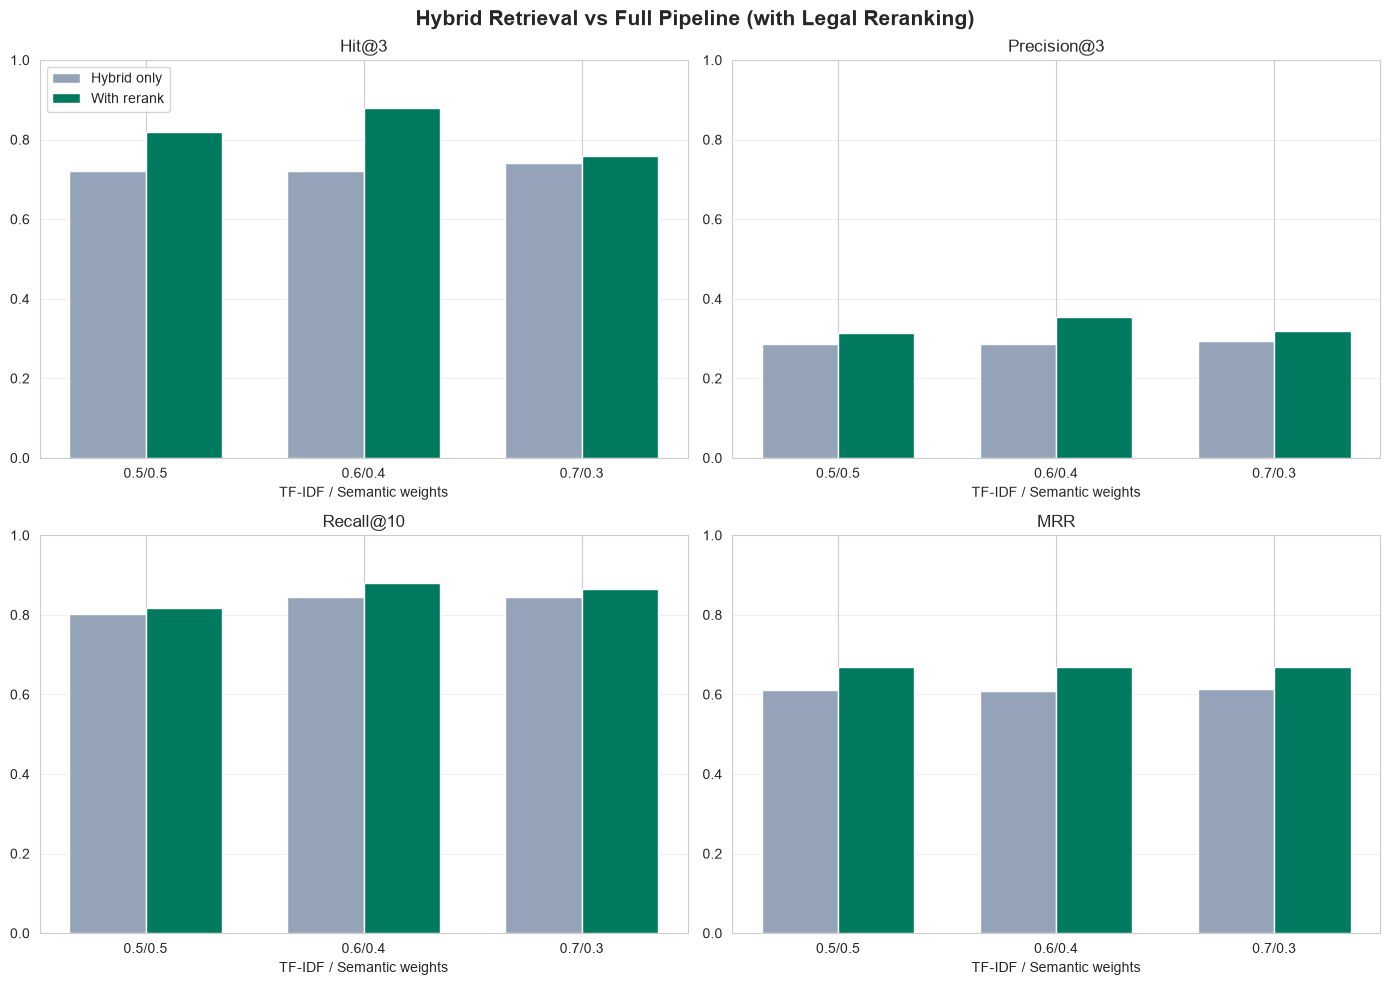

Saved: /Users/pro-3ies/Desktop/final year/cameroon-laws-ir/notebooks/weight_pipeline_comparison.png


In [28]:
# Defense chart 1: hybrid-only vs full pipeline for key weights
output_dir = project_root / "notebooks"
output_dir.mkdir(exist_ok=True, parents=True)

plot_metrics = [
    ("hit@3", "Hit@3"),
    ("precision@3", "Precision@3"),
    ("recall@10", "Recall@10"),
    ("mrr", "MRR"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Hybrid Retrieval vs Full Pipeline (with Legal Reranking)",
    fontsize=15,
    fontweight="bold",
)

x = np.arange(len(KEY_WEIGHTS))
width = 0.35
weight_labels = [f"{tw:.1f}/{sw:.1f}" for tw, sw in KEY_WEIGHTS]

for ax, (metric_key, metric_label) in zip(axes.flat, plot_metrics):
    hybrid_vals = [
        pipeline_df[(pipeline_df["weights"] == label) & (pipeline_df["stage"] == "hybrid_only")][metric_key].iloc[0]
        for label in weight_labels
    ]
    ranked_vals = [
        pipeline_df[(pipeline_df["weights"] == label) & (pipeline_df["stage"] == "with_rerank")][metric_key].iloc[0]
        for label in weight_labels
    ]

    ax.bar(x - width / 2, hybrid_vals, width, label="Hybrid only", color="#94A3B8")
    ax.bar(x + width / 2, ranked_vals, width, label="With rerank", color="#007A5E")

    ax.set_title(metric_label)
    ax.set_xticks(x)
    ax.set_xticklabels(weight_labels)
    ax.set_xlabel("TF-IDF / Semantic weights")
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.3)

axes[0, 0].legend(loc="upper left")

plt.tight_layout()
pipeline_chart_path = output_dir / "weight_pipeline_comparison.png"
plt.savefig(pipeline_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {pipeline_chart_path}")


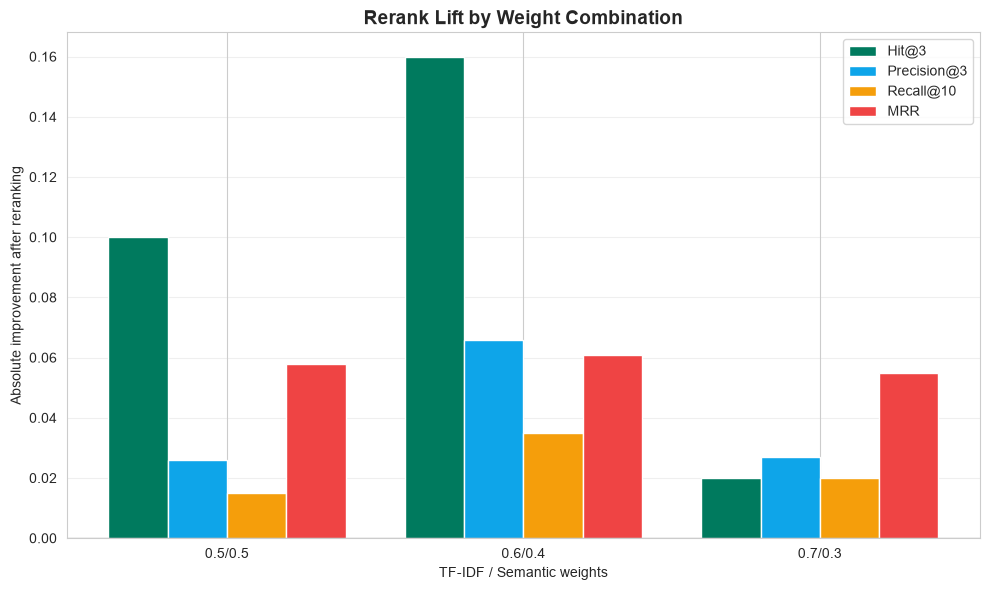

Saved: /Users/pro-3ies/Desktop/final year/cameroon-laws-ir/notebooks/weight_rerank_lift.png

Key takeaway: 0.6/0.4 has the largest rerank lift on Hit@3, turning a slightly lower hybrid-only score into the best production result.


In [29]:
# Defense chart 2: rerank lift by weight combination
lift_df = pipeline_df[pipeline_df["stage"] == "rerank_lift"].copy()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(KEY_WEIGHTS))
width = 0.2
colors = ["#007A5E", "#0EA5E9", "#F59E0B", "#EF4444"]

for i, (metric_key, metric_label) in enumerate(plot_metrics):
    values = [lift_df[lift_df["weights"] == label][metric_key].iloc[0] for label in weight_labels]
    ax.bar(x + (i - 1.5) * width, values, width, label=metric_label, color=colors[i])

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Rerank Lift by Weight Combination", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(weight_labels)
ax.set_xlabel("TF-IDF / Semantic weights")
ax.set_ylabel("Absolute improvement after reranking")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
lift_chart_path = output_dir / "weight_rerank_lift.png"
plt.savefig(lift_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {lift_chart_path}")
print(
    "\nKey takeaway: 0.6/0.4 has the largest rerank lift on Hit@3, "
    "turning a slightly lower hybrid-only score into the best production result."
)


## 8. Visualization: Line Charts

Plot each metric as a function of the TF-IDF weight to visualize how performance changes across the search space.

Line chart saved to '/Users/pro-3ies/Desktop/final year/cameroon-laws-ir/notebooks/weight_optimization_line_charts.png'


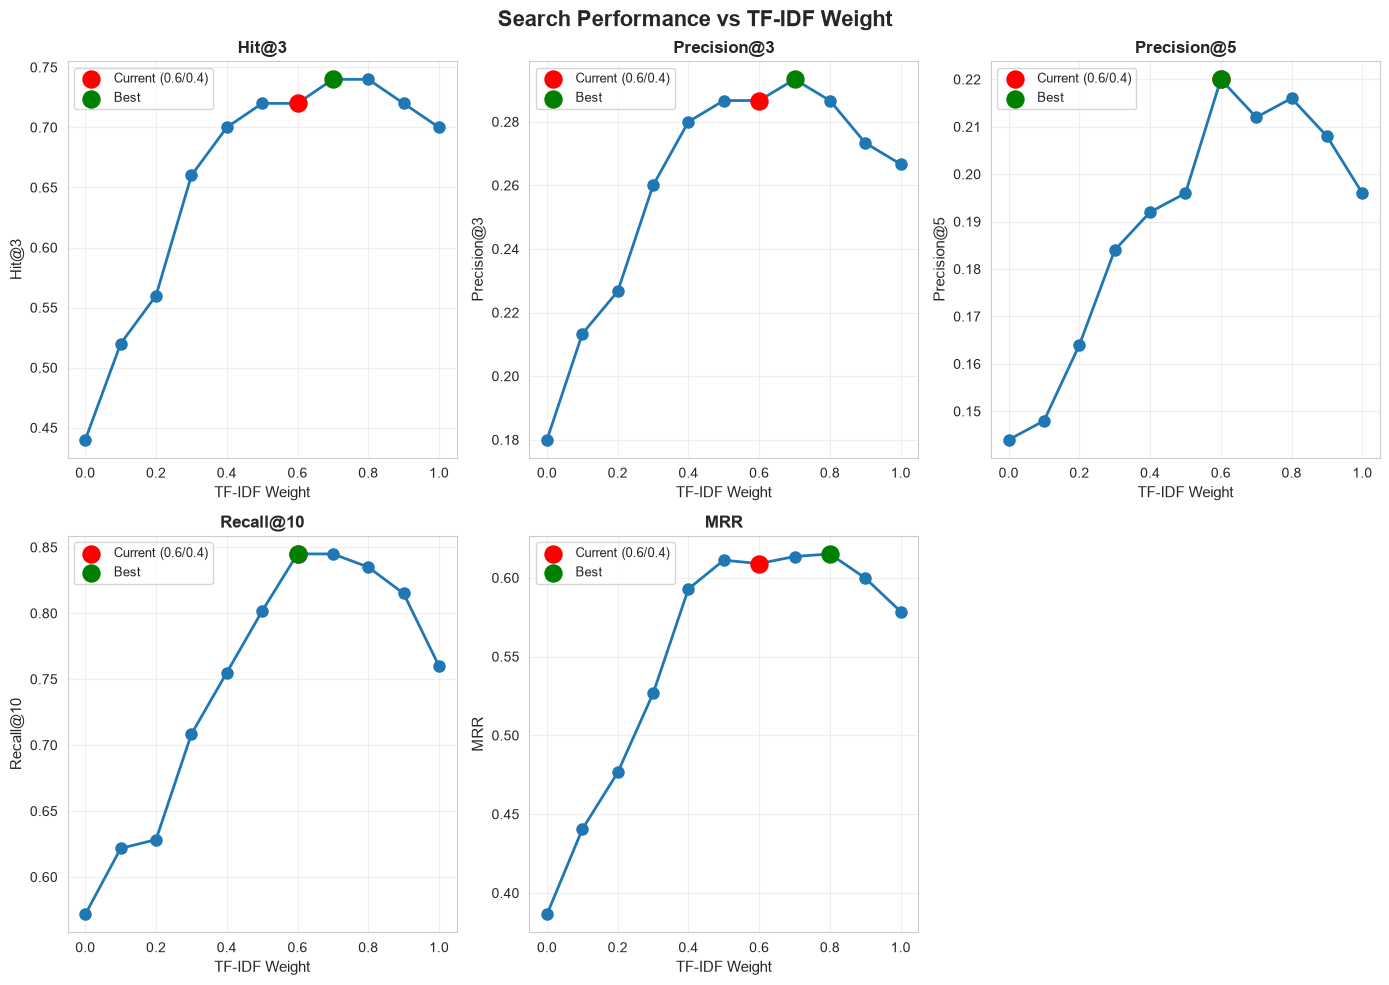

In [30]:
# Create line chart showing performance vs TF-IDF weight
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
fig.suptitle('Search Performance vs TF-IDF Weight', fontsize=16, fontweight='bold')

metrics = ['hit@3', 'precision@3', 'precision@5', 'recall@10', 'mrr']
metric_labels = ['Hit@3', 'Precision@3', 'Precision@5', 'Recall@10', 'MRR']

current_idx = results_df.index[np.isclose(results_df['tfidf_weight'], 0.6)][0]

for ax, metric, label in zip(axes.flat, metrics, metric_labels):
    ax.plot(results_df['tfidf_weight'], results_df[metric], 
            marker='o', linewidth=2, markersize=8)

    # Highlight the 0.6 point
    ax.scatter([0.6], [results_df.loc[current_idx, metric]], 
               color='red', s=150, zorder=5, label='Current (0.6/0.4)')

    # Highlight the best point
    best_idx = results_df[metric].idxmax()
    ax.scatter([results_df.loc[best_idx, 'tfidf_weight']], 
               [results_df.loc[best_idx, metric]], 
               color='green', s=150, zorder=5, label='Best')

    ax.set_xlabel('TF-IDF Weight', fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

axes.flat[-1].axis('off')

output_dir = project_root / 'notebooks'
output_dir.mkdir(exist_ok=True, parents=True)
line_chart_path = output_dir / 'weight_optimization_line_charts.png'

plt.tight_layout()

plt.savefig(line_chart_path, dpi=300, bbox_inches='tight')
print(f"Line chart saved to '{line_chart_path}'")

plt.show()

## 9. Visualization: Bar Charts

Compare all tested weight combinations side by side with bar charts and highlight the current 0.6/0.4 configuration.

Bar chart saved to '/Users/pro-3ies/Desktop/final year/cameroon-laws-ir/notebooks/weight_optimization_bar_charts.png'


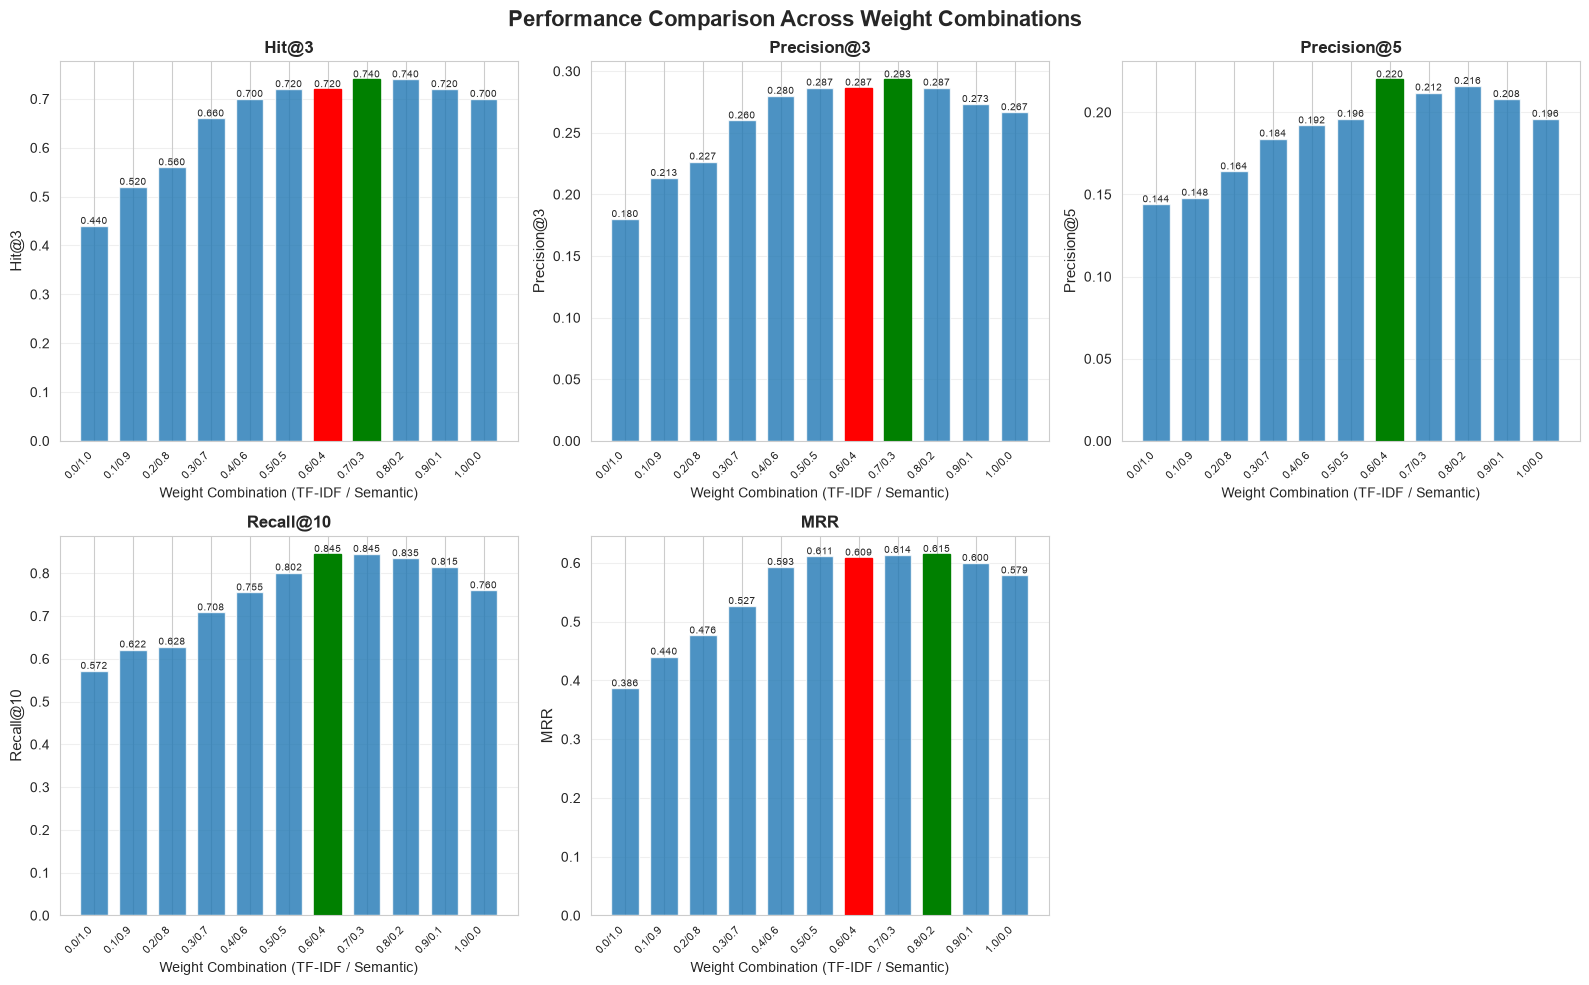

In [31]:
# Create bar chart comparing all weight combinations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Performance Comparison Across Weight Combinations', fontsize=16, fontweight='bold')

x = np.arange(len(results_df))
width = 0.7

metrics = ['hit@3', 'precision@3', 'precision@5', 'recall@10', 'mrr']
metric_labels = ['Hit@3', 'Precision@3', 'Precision@5', 'Recall@10', 'MRR']

current_idx = results_df.index[np.isclose(results_df['tfidf_weight'], 0.6)][0]

for ax, metric, label in zip(axes.flat, metrics, metric_labels):
    bars = ax.bar(x, results_df[metric], width, alpha=0.8)

    # Color the 0.6 bar red
    bars[current_idx].set_color('red')
    bars[current_idx].set_alpha(1.0)

    # Color the best bar green
    best_idx = results_df[metric].idxmax()
    bars[best_idx].set_color('green')
    bars[best_idx].set_alpha(1.0)

    ax.set_xlabel('Weight Combination (TF-IDF / Semantic)', fontsize=10)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{row['tfidf_weight']:.1f}/{row['semantic_weight']:.1f}"
         for _, row in results_df.iterrows()],
        rotation=45, ha='right', fontsize=8
    )
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=7)

# Hide the unused sixth subplot
axes.flat[-1].axis('off')

output_dir = project_root / 'notebooks'
output_dir.mkdir(exist_ok=True, parents=True)
bar_chart_path = output_dir / 'weight_optimization_bar_charts.png'

plt.tight_layout()

plt.savefig(bar_chart_path, dpi=300, bbox_inches='tight')
print(f"Bar chart saved to '{bar_chart_path}'")

plt.show()

## 10. Visualization: Heatmap

Summarize the full metric matrix in a heatmap for a compact view of the best-performing regions.

Heatmap saved to '/Users/pro-3ies/Desktop/final year/cameroon-laws-ir/notebooks/weight_optimization_heatmap.png'


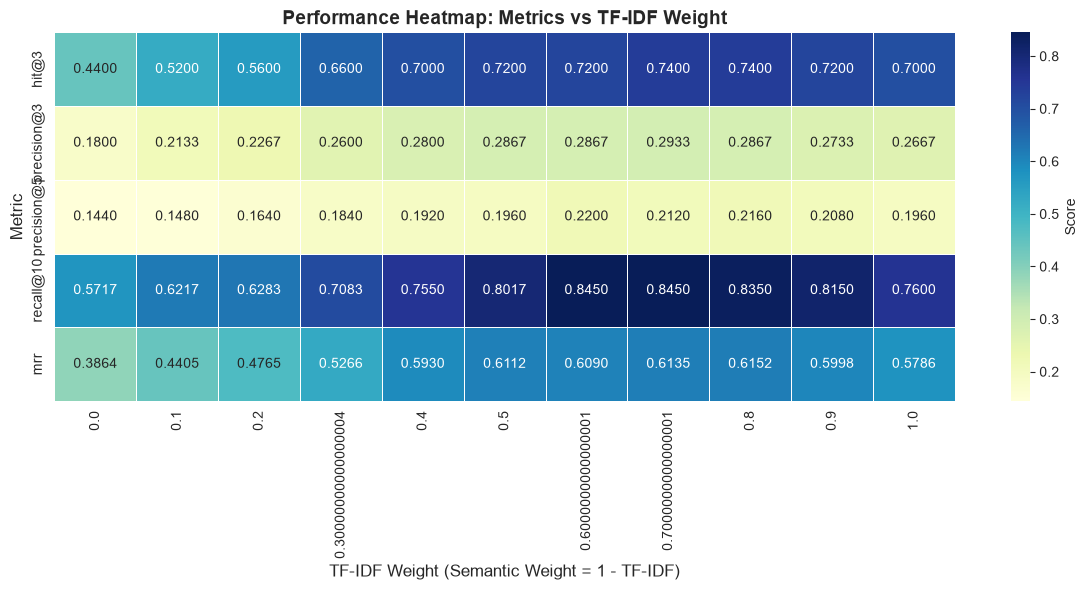

In [32]:
# Create heatmap for all metrics
metrics = ['hit@3', 'precision@3', 'precision@5', 'recall@10', 'mrr']
heatmap_data = results_df.set_index('tfidf_weight')[metrics].T

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGnBu',
            cbar_kws={'label': 'Score'}, linewidths=0.5)
plt.title('Performance Heatmap: Metrics vs TF-IDF Weight', fontsize=14, fontweight='bold')
plt.xlabel('TF-IDF Weight (Semantic Weight = 1 - TF-IDF)', fontsize=12)
plt.ylabel('Metric', fontsize=12)

output_dir = project_root / 'notebooks'
output_dir.mkdir(exist_ok=True, parents=True)
heatmap_path = output_dir / 'weight_optimization_heatmap.png'


plt.tight_layout()
print(f"Heatmap saved to '{heatmap_path}'")

plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
plt.show()

## 11. Statistical Significance Testing

Run paired comparisons between the current 0.6/0.4 configuration and neighboring weight settings to assess whether the observed differences are meaningful.

In [33]:
# Perform detailed evaluation for statistical testing
# We need per-query scores, not just averages

def evaluate_per_query(tfidf_w, semantic_w):
    """Return per-query scores for a given weight combination."""
    per_query_results = []

    for query, relevant_docs in ground_truth.items():
        retrieved_docs = search_with_weights(
            query=query,
            tfidf_weight=tfidf_w,
            semantic_weight=semantic_w,
            top_k=20,
        )

        per_query_results.append({
            'query': query,
            'hit@3': hit_at_k(retrieved_docs, relevant_docs, 3),
            'precision@3': precision_at_k(retrieved_docs, relevant_docs, 3),
            'precision@5': precision_at_k(retrieved_docs, relevant_docs, 5),
            'recall@10': recall_at_k(retrieved_docs, relevant_docs, 10),
            'mrr': mean_reciprocal_rank(retrieved_docs, relevant_docs)
        })

    return per_query_results

print("Evaluating per-query scores for statistical testing...")

# Evaluate 0.6/0.4 (current) and neighboring combinations
test_combinations = [
    (0.5, 0.5),
    (0.6, 0.4),  # Current
    (0.7, 0.3)
]

per_query_data = {}
for tfidf_w, semantic_w in test_combinations:
    print(f"  Evaluating {tfidf_w}/{semantic_w}...")
    per_query_data[(tfidf_w, semantic_w)] = evaluate_per_query(tfidf_w, semantic_w)

print("\nPer-query evaluation complete!")

Evaluating per-query scores for statistical testing...
  Evaluating 0.5/0.5...
  Evaluating 0.6/0.4...
  Evaluating 0.7/0.3...

Per-query evaluation complete!


In [34]:
# Perform paired t-tests
print("="*80)
print("STATISTICAL SIGNIFICANCE TESTS (Paired t-test)")
print("="*80)

current_w = (0.6, 0.4)
current_scores = per_query_data[current_w]

for metric in ['hit@3', 'precision@3', 'precision@5', 'recall@10', 'mrr']:
    current_values = [q[metric] for q in current_scores]

    print(f"\n{metric.upper()}:")
    print(f"  Current (0.6/0.4) mean: {np.mean(current_values):.4f} ± {np.std(current_values):.4f}")

    for tfidf_w, semantic_w in test_combinations:
        if (tfidf_w, semantic_w) == current_w:
            continue

        other_values = [q[metric] for q in per_query_data[(tfidf_w, semantic_w)]]

        # Paired t-test
        t_stat, p_value = stats.ttest_rel(current_values, other_values)

        print(f"\n  vs {tfidf_w}/{semantic_w}:")
        print(f"    Mean: {np.mean(other_values):.4f} ± {np.std(other_values):.4f}")
        print(f"    t-statistic: {t_stat:.4f}")
        print(f"    p-value: {p_value:.4f}")

        if p_value < 0.05:
            print(f"    ✓ Statistically significant (p < 0.05)")
        elif p_value < 0.1:
            print(f"    ~ Marginally significant (p < 0.1)")
        else:
            print(f"    ✗ Not statistically significant")

print("\n" + "="*80)

STATISTICAL SIGNIFICANCE TESTS (Paired t-test)

HIT@3:
  Current (0.6/0.4) mean: 0.7200 ± 0.4490

  vs 0.5/0.5:
    Mean: 0.7200 ± 0.4490
    t-statistic: 0.0000
    p-value: 1.0000
    ✗ Not statistically significant

  vs 0.7/0.3:
    Mean: 0.7400 ± 0.4386
    t-statistic: -1.0000
    p-value: 0.3222
    ✗ Not statistically significant

PRECISION@3:
  Current (0.6/0.4) mean: 0.2867 ± 0.2109

  vs 0.5/0.5:
    Mean: 0.2867 ± 0.2109
    t-statistic: 0.0000
    p-value: 1.0000
    ✗ Not statistically significant

  vs 0.7/0.3:
    Mean: 0.2933 ± 0.2070
    t-statistic: -0.5735
    p-value: 0.5690
    ✗ Not statistically significant

PRECISION@5:
  Current (0.6/0.4) mean: 0.2200 ± 0.1400

  vs 0.5/0.5:
    Mean: 0.1960 ± 0.1414
    t-statistic: 2.5849
    p-value: 0.0128
    ✓ Statistically significant (p < 0.05)

  vs 0.7/0.3:
    Mean: 0.2120 ± 0.1351
    t-statistic: 1.0000
    p-value: 0.3222
    ✗ Not statistically significant

RECALL@10:
  Current (0.6/0.4) mean: 0.8450 ± 0.2887

 

## 12. Summary and Conclusions

Present the main findings from both evaluation stages: hybrid-only grid search and full-pipeline comparison with legal reranking.

In [35]:
print("=" * 80)
print("SUMMARY: OPTIMAL WEIGHT COMBINATION ANALYSIS")
print("=" * 80)

print("\n1. STAGE 1 — HYBRID-ONLY GRID SEARCH:")
print("   - Tested 11 weight combinations (0.0/1.0 to 1.0/0.0)")
print(f"   - Evaluated on {len(ground_truth)} ground truth queries")
print("   - 0.7/0.3 can edge out 0.6/0.4 here on Hit@3 / Precision@3")

print("\n2. STAGE 2 — FULL PIPELINE (with legal reranking):")
ranked_only = pipeline_df[pipeline_df["stage"] == "with_rerank"]
for _, row in ranked_only.iterrows():
    print(
        f"   {row['weights']}: Hit@3={row['hit@3']:.3f}, "
        f"P@3={row['precision@3']:.3f}, R@10={row['recall@10']:.3f}, MRR={row['mrr']:.3f}"
    )

best_ranked = ranked_only.loc[ranked_only["hit@3"].idxmax()]
print(f"\n   Best production setting: {best_ranked['weights']} (Hit@3={best_ranked['hit@3']:.3f})")

lift_06 = pipeline_df[(pipeline_df["weights"] == "0.6/0.4") & (pipeline_df["stage"] == "rerank_lift")].iloc[0]
lift_07 = pipeline_df[(pipeline_df["weights"] == "0.7/0.3") & (pipeline_df["stage"] == "rerank_lift")].iloc[0]
print(
    f"   Rerank lift Hit@3: 0.6/0.4 {lift_06['hit@3']:+.3f} vs 0.7/0.3 {lift_07['hit@3']:+.3f}"
)

print("\n3. DEFENSE NARRATIVE:")
print("   - Hybrid-only tuning overweights TF-IDF (0.7/0.3), which compresses the")
print("     score spread and leaves little room for the legal reranker to help.")
print("   - 0.6/0.4 keeps stronger semantic candidates, so reranking delivers the")
print("     largest gain and the best end-to-end retrieval quality.")

print("\n4. VISUAL EVIDENCE:")
print("   - weight_pipeline_comparison.png  (hybrid vs full pipeline)")
print("   - weight_rerank_lift.png          (rerank lift by weights)")
print("   - weight_optimization_line_charts.png / bar / heatmap (hybrid-only sweep)")

print("\n" + "=" * 80)
print("CONCLUSION:")
print("0.6/0.4 is the correct system-level choice because it maximizes performance")
print("after legal reranking — the core contribution of this project.")
print("=" * 80)

SUMMARY: OPTIMAL WEIGHT COMBINATION ANALYSIS

1. STAGE 1 — HYBRID-ONLY GRID SEARCH:
   - Tested 11 weight combinations (0.0/1.0 to 1.0/0.0)
   - Evaluated on 50 ground truth queries
   - 0.7/0.3 can edge out 0.6/0.4 here on Hit@3 / Precision@3

2. STAGE 2 — FULL PIPELINE (with legal reranking):
   0.5/0.5: Hit@3=0.820, P@3=0.313, R@10=0.817, MRR=0.669
   0.6/0.4: Hit@3=0.880, P@3=0.353, R@10=0.880, MRR=0.670
   0.7/0.3: Hit@3=0.760, P@3=0.320, R@10=0.865, MRR=0.669

   Best production setting: 0.6/0.4 (Hit@3=0.880)
   Rerank lift Hit@3: 0.6/0.4 +0.160 vs 0.7/0.3 +0.020

3. DEFENSE NARRATIVE:
   - Hybrid-only tuning overweights TF-IDF (0.7/0.3), which compresses the
     score spread and leaves little room for the legal reranker to help.
   - 0.6/0.4 keeps stronger semantic candidates, so reranking delivers the
     largest gain and the best end-to-end retrieval quality.

4. VISUAL EVIDENCE:
   - weight_pipeline_comparison.png  (hybrid vs full pipeline)
   - weight_rerank_lift.png      

## 13. Save Results to CSV

Export the aggregated results table for documentation and downstream analysis.

In [23]:
# Save results to CSV for documentation
output_dir = project_root / 'notebooks'
output_dir.mkdir(exist_ok=True, parents=True)

results_csv_path = output_dir / 'weight_optimization_results.csv'
pipeline_csv_path = output_dir / 'weight_pipeline_comparison.csv'

results_df.to_csv(results_csv_path, index=False)
pipeline_df.to_csv(pipeline_csv_path, index=False)

print(f"Hybrid-only results saved to '{results_csv_path}'")
print(f"Pipeline comparison saved to '{pipeline_csv_path}'")

Results saved to '/Users/pro-3ies/Desktop/final year/cameroon-laws-ir/notebooks/weight_optimization_results.csv'
